In [21]:
%matplotlib inline
import numpy as np
from glob import glob
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
from scipy.stats import mannwhitneyu
# from scipy.stats import f_oneway
from scipy.stats import ttest_ind
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from os.path import exists
plt.rcParams['figure.dpi'] = 100
from adjustText import adjust_text

In [11]:
## Define set fo genes to plot

# genes_essent = ['HK2', 'AMY1A', 'SI', 'SLC5A1', 'TAS1R3', 'LCT']
# genes_essent = ['SGCD', 'MYOCD', 'MYOF', 'MANBA', 'GCAT', 'GLB1L2', 'DMD', 'CNMD', 'CHST4', 'ASPG', 'B3GALNT1']
# genes_essent = ['ANK2', 'ANO1', 'JADE1', 'FANCM', 'FAT1', 'FAT4', 'GRIP1', 'GRIP2', 'SNX19', 'HK1', 'HK2',
#                 'HK3', 'HKDC1', 'GRIK1', 'GRIK3', 'GRIK4', 'HYAL1', 'HYAL2']
# genes_essent = ['B3GALT1', 'B4GALT5', 'B3GALNT1', 'ACAT1', 'ACSS1', 'ASPG', 'FH', 'GCSH', 'SORD',
#                 'MDH2', 'MLYCD', 'ALDH4A1', 'ALDH5A1', 'ALDH6A1', 'GOT1', 'GOT2', 'MCCC1', 'MCCC2']
# genes_essent = ['APOBEC2', 'CASZ1', 'COL13A1', 'PRDM16', 'KCNQ1', 'TRIM63', 'TPM4', 'AGTRAP', 'ASIC2', 
#                 'EDIL3', 'SLC22A18', 'EMP2', 'SLC30A2', 'NEUROG3', 'FOXL1', 'HNF1B', 'ONECUT1', 'TBX2', 
#                 'GMDS', 'ACACB', 'AGPAT2', 'LMF1', 'MVK', 'ACSF3', 'KYNU', 'MMAB', 'MVD', 'PERM1', 'SCL8B1']
# genes_essent = ['AGPAT2', 'AGTRAP', 'CASZ1', 'DPP10', 'FAT1', 'GCAT', 'LMF1', 'MMAB', 'MYOCD', 'MYOF', 'PRDM16',
#                 'RPH3AL', 'FAM83D', 'FHL3', 'HSCB', 'MFSD2B', 'PFKL', 'SLC15A5', 'ZNF516']
# genes_essent = ['ACACA_rna-XM_015295696', 'NEU2', 'BDH1', 'MLN', 'SIK3', 'ONECUT1', 'ARRDC4', 'HYAL1', 'ACACB']

## Genes that got A-rating
# with open('A_rank_genes.lst', 'r') as inf:
#     genes_essent = inf.read().rstrip().split('\n')

## BCCA genes
# with open('BCCA_genes.lst', 'r') as inf:
#     genes_essent = inf.read().rstrip().split('\n')


# genes_essent = ['HK1', 'HK2', 'HK3', 'HKDC1']
# genes_essent = ['HK3']
# genes_essent = ['KLF15','KCNJ5','SLC8B1','TBX2','ANK2','ANO1','SNX19', 'SNX7', 'TRPM5', 'AGMO', 'HNF1B']

## T2D genes
# with open('t2d_genes.causal_strong.lst', 'r') as inf:
#     genes_essent = inf.read().rstrip().split('\n')

## FA synthesis genes
# genes_essent = ['FASN', 'ACACA_rna-XM_015295696', 'ACSL1', 'ACSL3', 'ACSL4', 'ACSL5', 'ACSL6']

## Heart genes (Michale's notes)
# genes_essent = ['ATP2A2', 'ATP2A3', 'RYR2', 'MYOF', 'MYOCD', 'KCNJ5', 'MCU', 
#                 'SLC8B1', 'CNMD', 'TBX2', 'ANK2', 'SGCD', 'NEBL']

## ATP synthase subunits genes
# genes_essent = ['ATP5C1', 'ATP5F1B', 'ATP5MC1', 'ATP5MC3', 'ATP5ME', 'ATP5MF', 'ATP5O',
#                 'ATP5PD', 'ATP5PF', 'ATP5S']


## ansrel 3-4 way convergence genes
# genes_essent = ['ABCA7', 'BMP8A', 'JAM3', 'KCNK5', 'MLXIPL', 'RAB11FIP4', 'STK39', 'CD247', 'EHD4', 'KCNK16', 
#                 'NPSR1', 'OMA1', 'PDGFC', 'PLA2G4E', 'PTPN2', 'SHROOM3', 'ZDHHC2']
# genes_essent = ['KCNK5', 'KCNK16', 'KCNK17', 'KCNK18']

## genes in INTRA but not in pairwise or extremes
# with open('intra_extreme_genes.lst', 'r') as inf:
#     genes_essent = inf.read().rstrip().split('\n')
    
## gene to checl for making sense of DESeq2 multifactor
# genes_essent = ['OBSCN', 'GNL2', 'ACAT1', 'HBBR', 'FOPNL', 'BRAF']
# genes_essent = ['MRPL58', 'FKBP9', 'RNF111', 'SLC38A2']
# genes_essent = ['ES1ML2', 'ADD3', 'CKB']
# genes_essent = ['ACACB', 'ACACA']
# dir_path = '/Users/osipova/Documents/LabDocs/Bird_transcriptomics/Transcriptome_for_NectarGenomics/Multifactor_DESeq2_results/'
# with open(dir_path + 'NDUF_genes.lst', 'r') as inf:
#     genes_essent = inf.read().rstrip().split('\n')

# with open('bp_vidua_gene_losses.lst', 'r') as inf:
#     genes_essent = inf.read().rstrip().split('\n')
# genes_essent = ['SI', 'ACAC']

# dir_path = '/Users/osipova/Documents/LabDocs/NectarivoryProject/Expression_from_counts/'
# with open(dir_path + 'difficult_candidate_genes.lst', 'r') as inf:
#     genes_essent = inf.read().rstrip().split('\n')

genes_essent = ['PARD6G', 'reg_12989']

PARD6G


/Users/osipova/local/Homebrew/lib/python3.7/site-packages/seaborn/categorical.py:1143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  hue_mask = self.plot_hues[i] == hue_level
/Users/osipova/local/Homebrew/lib/python3.7/site-packages/seaborn/categorical.py:1143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  hue_mask = self.plot_hues[i] == hue_level
/Users/osipova/local/Homebrew/lib/python3.7/site-packages/seaborn/categorical.py:1143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  hue_mask = self.plot_hues[i] == hue_level


reg_12989


/Users/osipova/local/Homebrew/lib/python3.7/site-packages/seaborn/categorical.py:1143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  hue_mask = self.plot_hues[i] == hue_level
/Users/osipova/local/Homebrew/lib/python3.7/site-packages/seaborn/categorical.py:1143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  hue_mask = self.plot_hues[i] == hue_level
/Users/osipova/local/Homebrew/lib/python3.7/site-packages/seaborn/categorical.py:1143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  hue_mask = self.plot_hues[i] == hue_level


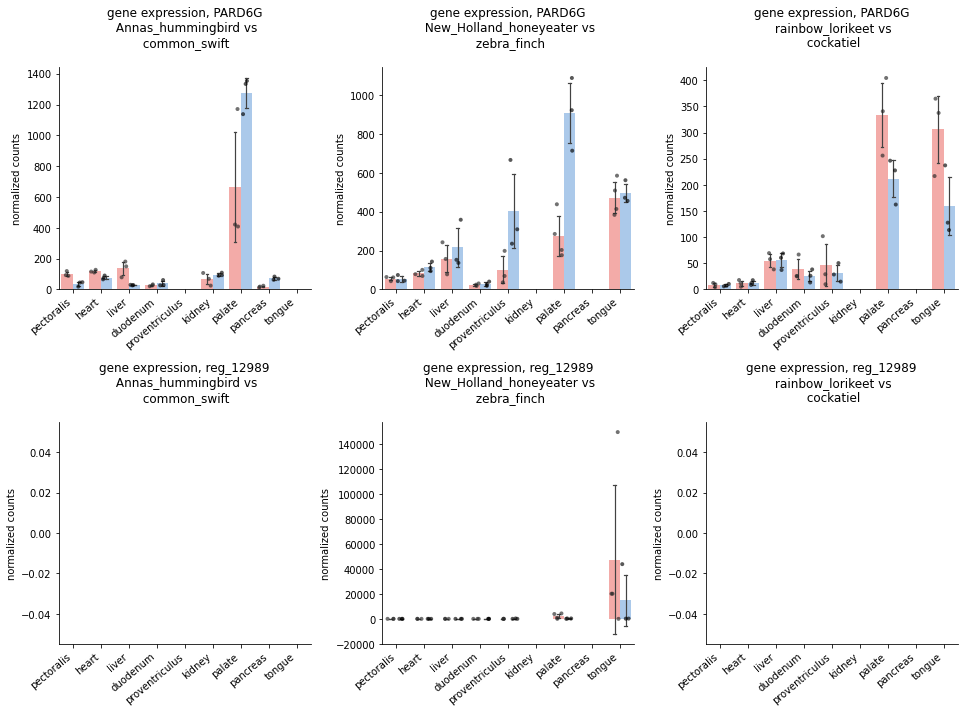

In [12]:
## Plot gene expression by tissue
# tissues = ['pectoralis', 'heart', 'liver', 'duodenum', 'palate', 'pancreas', 'kidney', 
#            'lung', 'fat', 'proventriculus', 'tongue', 'gonads' ]
tissues = ['pectoralis', 'heart', 'liver', 'duodenum', 'proventriculus', 'kidney', 'palate', 'pancreas', 'tongue']
# tissues = ['pectoralis', 'liver']

N_genes = len(genes_essent)
N_tissues = len(tissues)
N = 3

pairs = [('Annas_hummingbird', 'common_swift'),
         ('New_Holland_honeyeater', 'zebra_finch'),
         ('rainbow_lorikeet', 'cockatiel')]


## plot
fig, axes = plt.subplots(N_genes, N, figsize=(1.5*N_tissues, 5*N_genes))
p = sns.color_palette('pastel', n_colors=4)
p = [p[3], p[0]]
sns.set_palette(p)


for j in range(N_genes):
    gene = genes_essent[j]
    print(gene)
    dir_path = '/Users/osipova/Documents/LabDocs/NectarivoryProject/Expression_from_counts/'
    file_name = '{}/norm_counts.tsv'.format(gene)
    file_data = glob(dir_path + file_name)[0]
    df = pd.read_csv(file_data, sep='\t')

    for i in range(N):
        axi = axes[j][i]

        df_t = df[df['tissue'].isin(tissues)]
        df_pair = df_t[df_t['bird'].isin(pairs[i])]

        sns.barplot(ax=axi, data=df_pair, x='tissue', y='count', hue='bird', hue_order=pairs[i],
                    order=tissues, errwidth=1.2, capsize=.1, ci='sd')
        sns.stripplot(ax=axi, data=df_pair, x='tissue', y='count', hue='bird', hue_order=pairs[i],
                     order=tissues, color='k', s=4, alpha=0.65, dodge=True , jitter=0.3)

        # ax1.set(ylim=(1, 10000))
        # ax2.set(ylim=(1, 10000))
    #     if i == 0:
    #         axi.set(yscale='log')
        axi.set_xticklabels(axi.get_xticklabels(), rotation=40, ha="right")
        axi.legend([],[], frameon=False)
        sns.despine(fig=None, ax=None, left=False, bottom=False, offset=None, trim=False)
        axi.set_title('gene expression, {}\n {}\n'.format(gene, ' vs\n '.join(pairs[i])))
        axi.set_xlabel('')
        axi.set_ylabel('normalized counts')
    #     axi.set(ylim=(0, 10500))

        plt.tight_layout()
# pdf_name = 'A_rank_norm_counts_ALL_tissues.all_pairs.pdf'
# pdf_name = 'HEX_norm_counts_ALL_tissues.all_pairs.pdf'
# pdf_name = 't2d_norm_counts_ALL_tissues.all_pairs.pdf'
# pdf_name = 'heart_genes.norm_counts_ALL_tissues.all_pairs.pdf'
# pdf_name = 'HEX.norm_counts.12_tissues.all_pairs.pdf'
# pdf_name = 'rank3-4.norm_counts.ALL_tissues.all_pairs.pdf'
# pdf_name = 'intra_not_pairwise.norm_counts.pect_liver.all_pairs.pdf'
# pdf_name = 'two_setups_deseq2_multifactor.pdf'
# pdf_name = 'bp_vidua_gene_losses.pdf'
# pdf_name = 'ACACA_ACACB.ALL_tissues.all_pairs.pdf'
# pdf_name = 'SI.ALL_tissues.all_pairs.pdf'
pdf_name = 'difficult_candidate_genes.ALL_tissues.all_pairs.pdf'

# fig.savefig(pdf_name, bbox_inches='tight') 

In [38]:
t = 'liver'
g = 'ACACA'
for i in range(3):
    sp1 = pairs[i][0]
    sp2 = pairs[i][1]
    df_t = df[df['tissue']==t]
    df_pair = df_t[df_t['bird'].isin(pairs[i])]

    pval = mannwhitneyu(df_pair[df_pair['bird']==sp1]['count'], 
                        df_pair[df_pair['bird']==sp2]['count'],
                        alternative='two-sided')[1]
    print('for gene {} tissue {} species {} t-test p-value = {}'.format(g, t, sp1, pval))


for gene ACACA tissue liver species Annas_hummingbird t-test p-value = 0.08085559837005224
for gene ACACA tissue liver species New_Holland_honeyeater t-test p-value = 0.08085559837005224
for gene ACACA tissue liver species rainbow_lorikeet t-test p-value = 0.08085559837005224


# 

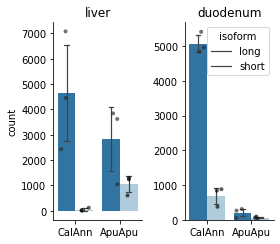

In [39]:
file_name = 'MLXIPL/long_short.isoform.calAnn.apuApu.tsv'
file_data = glob(dir_path + file_name)[0]
df_mlxipl = pd.read_csv(file_data, sep='\t')


fig, axes = plt.subplots(1, 2, figsize=(4, 3.5))
p = sns.color_palette('Paired', n_colors=6)
p = [p[1], p[0], p[5], p[4]]
sns.set_palette(p)

sns.barplot(ax=axes[0], data=df_mlxipl[df_mlxipl['tissue']=='liver'], x='bird', y='count', hue='isoform',
            errwidth=1.2, capsize=.1, ci='sd')
sns.barplot(ax=axes[1], data=df_mlxipl[df_mlxipl['tissue']=='duodenum'], x='bird', y='count', hue='isoform',
            errwidth=1.2, capsize=.1, ci='sd')
sns.stripplot(ax=axes[0], data=df_mlxipl[df_mlxipl['tissue']=='liver'], x='bird', y='count', hue='isoform',
            color='k', s=4, alpha=0.65, dodge=True , jitter=0.3)
sns.stripplot(ax=axes[1], data=df_mlxipl[df_mlxipl['tissue']=='duodenum'], x='bird', y='count', hue='isoform',
            color='k', s=4, alpha=0.65, dodge=True , jitter=0.3)

sns.despine(fig=None, ax=None, left=False, bottom=False, offset=None, trim=False)
axes[0].set_title('liver')
axes[1].set_title('duodenum')
axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[0].legend([],[], frameon=False)
axes[1].legend(title='isoform', loc='upper right', labels=['long', 'short'])

plt.tight_layout()

pdf_name = 'long_short_isoform.MLXIPL.calAnn_apuApu.pdf'

# fig.savefig(pdf_name, bbox_inches='tight')

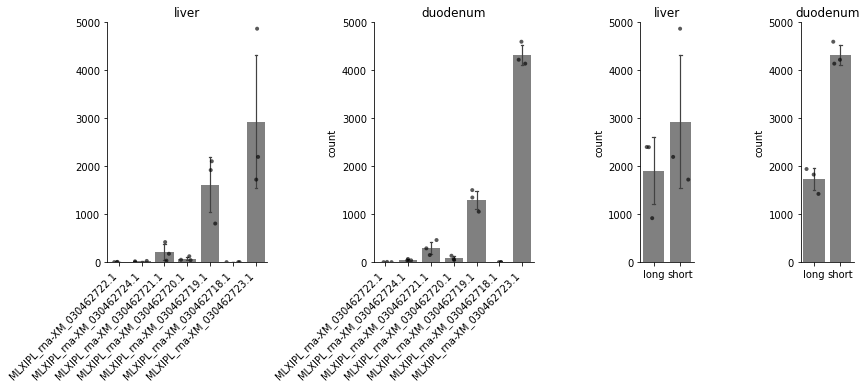

In [27]:
file_name = 'MLXIPL/all_ncbi_isoforms.calAnn.tsv'
file_data = glob(dir_path + file_name)[0]
df_mlxipl = pd.read_csv(file_data, sep='\t')


fig, axes = plt.subplots(1, 4, gridspec_kw={'width_ratios': [3, 3, 1, 1]}, figsize=(12, 5.5))
ax1, ax2, ax3, ax4 = axes[0], axes[1], axes[2], axes[3]
# p = sns.color_palette('Paired', n_colors=6)
# p = [p[1], p[0], p[5], p[4]]
# sns.set_palette(p)


all_iso = df_mlxipl[df_mlxipl['isoform'].str.startswith('MLXIPL')]
sum_iso = df_mlxipl[~df_mlxipl['isoform'].str.startswith('MLXIPL')]

## liver ALL sioforms
sns.barplot(ax=ax1, data=all_iso[all_iso['tissue']=='liver'], x='isoform', y='count', color='grey',
            errwidth=1.2, capsize=.1, ci='sd')
sns.stripplot(ax=ax1, data=all_iso[all_iso['tissue']=='liver'], x='isoform', y='count', 
            color='k', s=4, alpha=0.65, dodge=True , jitter=0.3)
## duodenum ALL sioforms
sns.barplot(ax=ax2, data=all_iso[all_iso['tissue']=='duodenum'], x='isoform', y='count', color='grey',
            errwidth=1.2, capsize=.1, ci='sd')
sns.stripplot(ax=ax2, data=all_iso[all_iso['tissue']=='duodenum'], x='isoform', y='count', 
            color='k', s=4, alpha=0.65, dodge=True , jitter=0.3)


## liver sum sioforms
sns.barplot(ax=ax3, data=sum_iso[sum_iso['tissue']=='liver'], x='isoform', y='count', color='grey',
            errwidth=1.2, capsize=.1, ci='sd')
sns.stripplot(ax=ax3, data=sum_iso[sum_iso['tissue']=='liver'], x='isoform', y='count', 
            color='k', s=4, alpha=0.65, dodge=True , jitter=0.3)
## duodenum sum sioforms
sns.barplot(ax=ax4, data=sum_iso[sum_iso['tissue']=='duodenum'], x='isoform', y='count', color='grey',
            errwidth=1.2, capsize=.1, ci='sd')
sns.stripplot(ax=ax4, data=sum_iso[sum_iso['tissue']=='duodenum'], x='isoform', y='count', 
            color='k', s=4, alpha=0.65, dodge=True , jitter=0.3)


sns.despine(fig=None, ax=None, left=False, bottom=False, offset=None, trim=False)
ax1.set_title('liver')
ax2.set_title('duodenum')
ax3.set_title('liver')
ax4.set_title('duodenum')
ax1.set_xticklabels(axes[0].get_xticklabels(), rotation=45, horizontalalignment='right')
ax2.set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')
ax1.set_xlabel('')
ax2.set_xlabel('')
ax1.set_ylabel('')
ax3.set_xlabel('')
ax4.set_xlabel('')
ax1.set(ylim=(0, 5000))
ax2.set(ylim=(0, 5000))
ax3.set(ylim=(0, 5000))
ax4.set(ylim=(0, 5000))
ax2.legend([],[], frameon=False)
# axes[1].legend(title='isoform', loc='upper right', labels=['long', 'short'])

plt.tight_layout()

# pdf_name = 'all_isoforms.MLXIPL.calAnn.pdf'

# fig.savefig(pdf_name, bbox_inches='tight')

## TLRs

In [27]:
dir_path = '/Users/osipova/Documents/LabDocs/for_Nicole/'
file_name = 'tlr4_meme.tsv'
file_data = glob(dir_path + file_name)[0]
df = pd.read_csv(file_data, sep='\t')

df['dnds'] = df['second_beta'] / df['alpha']
df['position'] = df['position'] + 1
df['corr_beta'] = [i if i > 1 else 0 for i in df['dnds']]

df.head(5)

,position,alpha,first_beta,psup-1,second_beta,psup-2,LRT,p-value,branches#,total_branch_length,MEMELOgL,FELLogL,FEL_alpha,FEL_beta,dN/dS,tmp,selection,codon_sites,dnds,corr_beta
0,1,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,1.000000,0,0,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,β,1,NaN,0.0
1,2,726.579059,6.104844,0.772029,6.030706,0.227971,0.0,0.666667,0,0,-15.811920,-14.749754,0.345706,723.153854,0.008300,*,ω,2,0.008300,0.0
2,3,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,1.000000,0,0,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,β,3,NaN,0.0
3,4,41.015118,0.000000,0.813079,0.127904,0.186921,0.0,0.666667,0,0,-6.917196,-6.921563,1.000000,43.520796,0.003118,*,ω,4,0.003118,0.0
4,5,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,1.000000,0,0,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,β,5,NaN,0.0


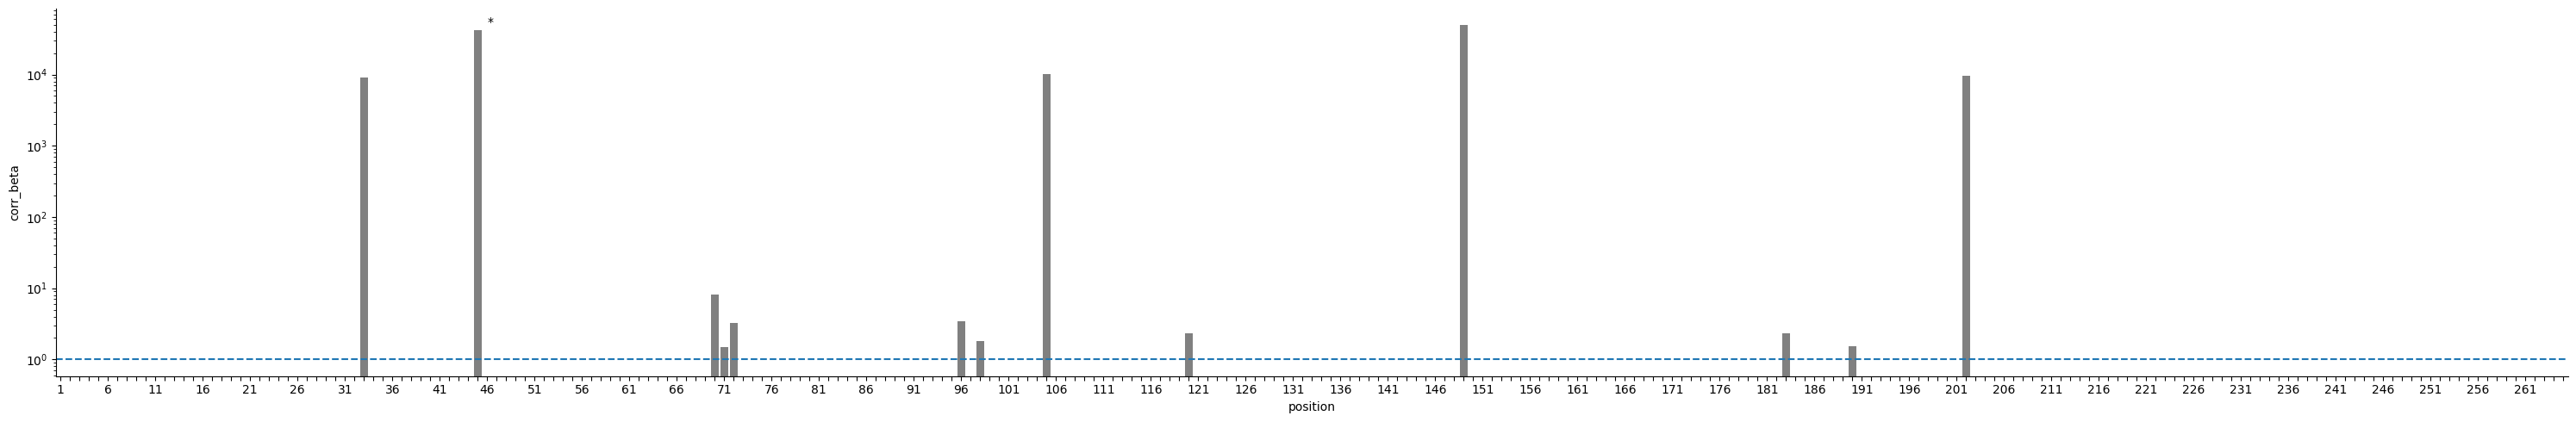

In [36]:
fig, axes = plt.subplots(figsize=(30, 5))

sns.barplot(data=df, x='position', y='corr_beta', color='grey')
dfi = df[df['p-value']<0.05]
# sns.barplot(data=dfi, x='position', y='corr_beta', color='red')

axes.axhline(1, ls='--')
axes.set(yscale="log")

labels = []
for x, y, p in zip(df['position'], df['corr_beta'], df['p-value']):
    if p < 0.05:
        labels.append(axes.text(x=x, y=y, s='*'))
adjust_text(labels, ax=axes)

for index, label in enumerate(axes.xaxis.get_ticklabels()):
    if index % 5 != 0:
        label.set_visible(False)

plt.tight_layout()
sns.despine(fig=None, ax=None, left=False, bottom=False, offset=None, trim=False)

In [35]:
dfi

,position,alpha,first_beta,psup-1,second_beta,psup-2,LRT,p-value,branches#,total_branch_length,MEMELOgL,FELLogL,FEL_alpha,FEL_beta,dN/dS,tmp,selection,codon_sites,dnds,corr_beta
44,45,0.030507,0.014866,0.272429,1281.507417,0.727571,5.247565,0.033187,1,0,-11.338712,-8.950946,0.091835,0.0,42006.62394,*,ω,45,42006.623897,42006.623897
